# Import Dependencies

In [1]:
import numpy as np
import pandas as pd
import pickle
from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parent))

from scripts import (train_linear_regression, train_random_forest, train_svr, 
                    train_knn, train_gradient_boosting, build_bilstm_model, 
                    train_bilstm_model, evaluate_model, plot_predictions, 
                    plot_training_history, plot_shap_summary)
import yaml

# Load Configuration

In [2]:
project_root = Path().resolve().parent
config_path = project_root / "config" / "config.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

#  Load Processed Data

In [3]:
import joblib
X_train_base = pd.read_csv(project_root / config["paths"]["processed"]["x_train_baseline"]).to_numpy()
X_test_base = pd.read_csv(project_root / config["paths"]["processed"]["x_test_baseline"]).to_numpy()
y_train_base = pd.read_csv(project_root / config["paths"]["processed"]["y_train_baseline"]).to_numpy().ravel()
y_test_base = pd.read_csv(project_root / config["paths"]["processed"]["y_test_baseline"]).to_numpy().ravel()

# BiLSTM data
processed_dir = project_root / "data" / "processed"
X_train_bilstm = joblib.load(processed_dir / config["paths"]["processed"]["X_train_bilstm"])
X_test_bilstm = joblib.load(processed_dir / config["paths"]["processed"]["X_test_bilstm"])
y_train_bilstm = joblib.load(processed_dir / config["paths"]["processed"]["y_train_bilstm"])
y_test_bilstm = joblib.load(processed_dir / config["paths"]["processed"]["y_test_bilstm"])

# Load scalers
y_scaler_bilstm = joblib.load(processed_dir / config["paths"]["processed"]["scaler_y_bilstm"])

c:\Users\maite\anaconda3\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.0.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# Train and Evaluate Baseline Models

## ML Models

### Linear Regression

Linear Regression Performance:
MSE: 0.39325543508774763
MAE: 0.4959372066484303
R^2 : 0.9997994245973834
RMSE: 0.6271008173234569
MAE: 0.50
MSE: 0.39
R2: 1.00
RMSE: 0.63


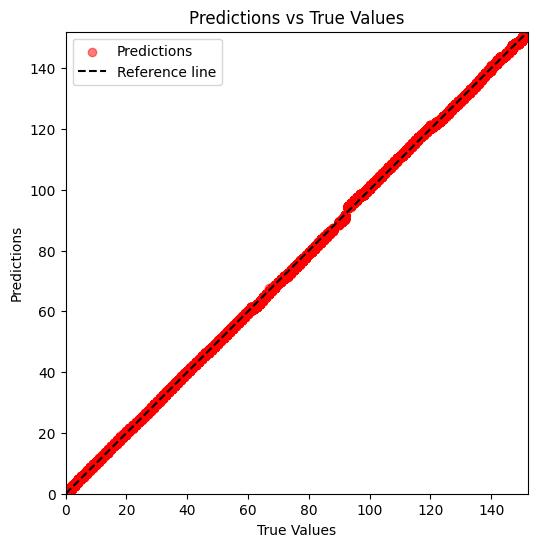

(0.39325543508774763, 0.4959372066484303, 0.9997994245973834)

In [ ]:
lin_reg = train_linear_regression(X_train_base, y_train_base)
mae, mse, rmse, r2 = evaluate_model(y_test_base, lin_reg.predict(X_test_base), "Linear Regression")
plot_predictions(y_test_base, lin_reg.predict(X_test_base), "Linear Regression")


### Random Forest

Random Forest Performance:
MSE: 0.09157159457247323
MAE: 0.007020151730293709
R^2 : 0.9999532949634999
RMSE: 0.3026079882826513
MAE: 0.01
MSE: 0.09
R2: 1.00
RMSE: 0.30


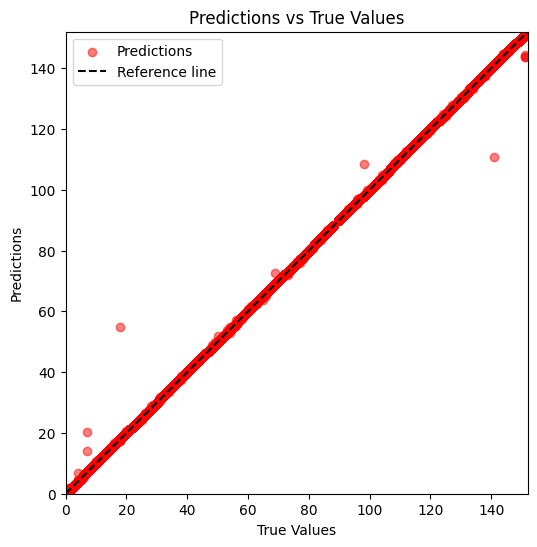

(0.09157159457247323, 0.007020151730293709, 0.9999532949634999)

In [ ]:

rf_reg = train_random_forest(X_train_base, y_train_base)
mae, mse, rmse, r2 = evaluate_model(y_test_base, rf_reg.predict(X_test_base), "Random Forest")
plot_predictions(y_test_base, rf_reg.predict(X_test_base), "Random Forest")

### Support Vector Regressor (SVR)

Support Vector Regressor Performance:
MSE: 0.4373205722833075
MAE: 0.33811930016468633
R^2 : 0.9997769496819829
RMSE: 0.6613021792518965
MAE: 0.34
MSE: 0.44
R2: 1.00
RMSE: 0.66


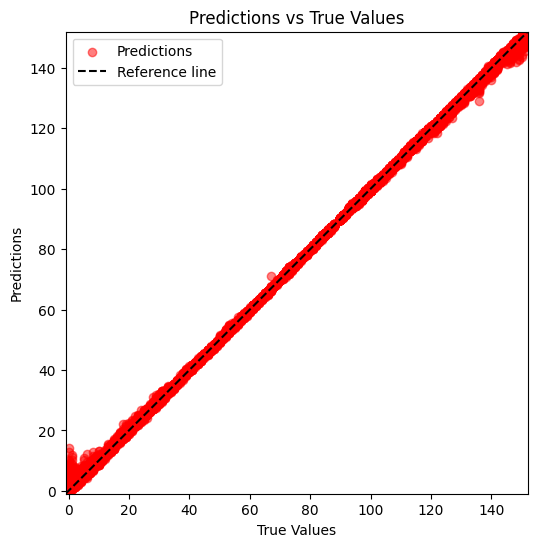

(0.4373205722833075, 0.33811930016468633, 0.9997769496819829)

In [ ]:

svr_reg = train_svr(X_train_base, y_train_base)
mae, mse, rmse, r2 = evaluate_model(y_test_base, svr_reg.predict(X_test_base), "SVR")
plot_predictions(y_test_base, svr_reg.predict(X_test_base), "SVR")


### K-Nearest Neighbors (KNN)

K-Nearest Neighbors Performance:
MSE: 0.6743784487782075
MAE: 0.43314229498564166
R^2 : 0.9996560410440367
RMSE: 0.8212054851121049
MAE: 0.43
MSE: 0.67
R2: 1.00
RMSE: 0.82


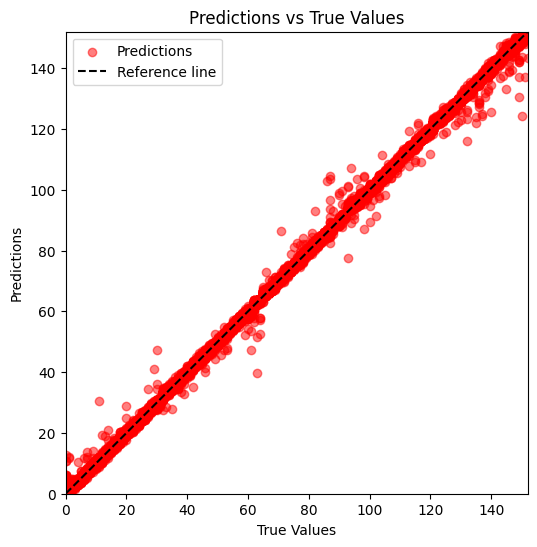

(0.6743784487782075, 0.43314229498564166, 0.9996560410440367)

In [ ]:

knn_reg = train_knn(X_train_base, y_train_base)
mae, mse, rmse, r2 = evaluate_model(y_test_base, knn_reg.predict(X_test_base), "KNN")
plot_predictions(y_test_base, knn_reg.predict(X_test_base), "KNN")

## Dl Models


### LSTM

In [ ]:
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
# Charger le dataset
MetroPT = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Conference 2024/Datasets/MetroPT.csv')

# Conversion de la colonne timestamp en datetime
MetroPT['timestamp'] = pd.to_datetime(MetroPT['timestamp'])

# Création de caractéristiques numériques à partir de la colonne timestamp
MetroPT['year'] = MetroPT['timestamp'].dt.year
MetroPT['month'] = MetroPT['timestamp'].dt.month
MetroPT['day'] = MetroPT['timestamp'].dt.day
MetroPT['hour'] = MetroPT['timestamp'].dt.hour
MetroPT['minute'] = MetroPT['timestamp'].dt.minute
MetroPT['second'] = MetroPT['timestamp'].dt.second

# Regroupement des données par 'month', 'day', 'hour', et 'minute'
grouped_data = MetroPT.groupby(['month', 'day', 'hour', 'minute']).agg({
    'TP2': 'mean',
    'TP3': 'mean',
    'H1': 'mean',
    'DV_pressure': 'mean',
    'Reservoirs': 'mean',
    'Oil_temperature': 'mean',
    'Motor_current': 'mean',
    'COMP': 'mean',
    'DV_eletric': 'mean',
    'Towers': 'mean',
    'MPG': 'mean',
    'LPS': 'mean',
    'Pressure_switch': 'mean',
    'Oil_level': 'mean',
    'Caudal_impulses': 'mean',
    'state': 'first',
    'failure_component': 'first',
    'RUL': 'mean'
}).reset_index()

# Afficher la taille du dataset final
print(f"Taille du dataset après regroupement : {grouped_data.shape}")
MetroPT = grouped_data

# Suppression de la colonne timestamp originale et autres colonnes non pertinentes
X = MetroPT.drop(columns=['RUL', 'state', 'failure_component'])
y = MetroPT['RUL']  # Données de sortie (RUL)

# Normalisation des données
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

# Normalisation de la cible (RUL)
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Création et entraînement du modèle pour la sélection des caractéristiques
n_top_features = 8
model = GradientBoostingRegressor(n_estimators=100)
model.fit(X_scaled, y_scaled.ravel())

# Importance des caractéristiques
importances = model.feature_importances_

# Affichage des scores d'importance pour chaque caractéristique
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)

# Sélection des n meilleures caractéristiques
top_features = importance_df['Feature'].head(n_top_features).values
print(f"Top {n_top_features} Features:", top_features)

# Création d'un nouveau DataFrame avec les n meilleures caractéristiques
X_top = X[top_features]

# Normalisation des données réduites
X_top_scaled = scaler_X.fit_transform(X_top)

# Define the cutoff index for the train-test split
cutoff_index = int(len(X_top) * 0.7)  # 70% train, 30% test

# Perform the sequential train-test split
X_train, X_test = X_top_scaled[:cutoff_index], X_top_scaled[cutoff_index:]
y_train, y_test = y_scaled[:cutoff_index], y_scaled[cutoff_index:]

# Mise en forme des données pour l'LSTM
n_steps = 10
X_train_seq = np.array([X_train[i:i+n_steps] for i in range(len(X_train)-n_steps)])
y_train_seq = y_train[n_steps:]

# Création du modèle LSTM
model = Sequential()
model.add(LSTM(64, input_shape=(n_steps, X_train_seq.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Entraînement du modèle
model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32, verbose=0)

# Prédictions
y_pred_seq = model.predict(X_train_seq).ravel()
y_pred = scaler_y.inverse_transform(y_pred_seq.reshape(-1, 1)).ravel()

# Evaluation
y_true = scaler_y.inverse_transform(y_train_seq.reshape(-1, 1)).ravel()

# Perform evaluation using the original scale of the target variable
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2: {r2:.2f}")
print(f"RMSE: {rmse:.2f}")

fig, ax = plt.subplots(figsize=(12, 6))

# Tracé des points
ax.scatter(y_true, y_pred, alpha=0.5, color='red', linestyle='-', label='Predictions')

# Tracé de la ligne de référence
min_val = min(min(y_true), min(y_pred))
max_val = max(max(y_true), max(y_pred))
ax.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Reference line')

# Mise en forme du graphique
ax.set_title('Predictions vs True Values')
ax.set_xlabel('True Values')
ax.set_ylabel('Predictions')
ax.legend()

# Ajustement des axes
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.set_aspect('equal')

plt.show()

Taille du dataset après regroupement : (155087, 22)
            Feature    Importance
0             month  5.382161e-01
7       DV_pressure  4.278812e-01
1               day  3.380129e-02
8        Reservoirs  5.569448e-05
2              hour  4.385325e-05
3            minute  1.468682e-06
10    Motor_current  2.922025e-07
6                H1  8.946106e-08
9   Oil_temperature  1.868636e-08
5               TP3  0.000000e+00
4               TP2  0.000000e+00
11             COMP  0.000000e+00
12       DV_eletric  0.000000e+00
13           Towers  0.000000e+00
14              MPG  0.000000e+00
15              LPS  0.000000e+00
16  Pressure_switch  0.000000e+00
17        Oil_level  0.000000e+00
18  Caudal_impulses  0.000000e+00
Top 8 Features: ['month' 'DV_pressure' 'day' 'Reservoirs' 'hour' 'minute' 'Motor_current'
 'H1']
3393/3393 [==============================] - 11s 3ms/step
MAE: 0.15
MSE: 0.03
R2: 1.00
RMSE: 0.17


# Proposed BiLSTM model

Chargement et prétraitement des données...

Construction du modèle BiLSTM...
Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 50, 8)]           0         
_________________________________________________________________
bidirectional_1 (Bidirection (None, 128)               37376     
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 129       
Total params: 37,505
Trainable params: 37,505
Non-trainable params: 0
_________________________________________________________________

Début de l'entraînement pour 50 epochs...
Train on 124029 samples, validate on 31008 samples
Epoch 1/15
124029/124029 [==============================] - 652s 5ms/sample - loss: 9.5760e-04 - mean_absolute_error: 0.0103 - val_loss: 3.1617e-05 - val_mean_absolute_error: 0.0048
Epoch 2/15
124029/124029 [======

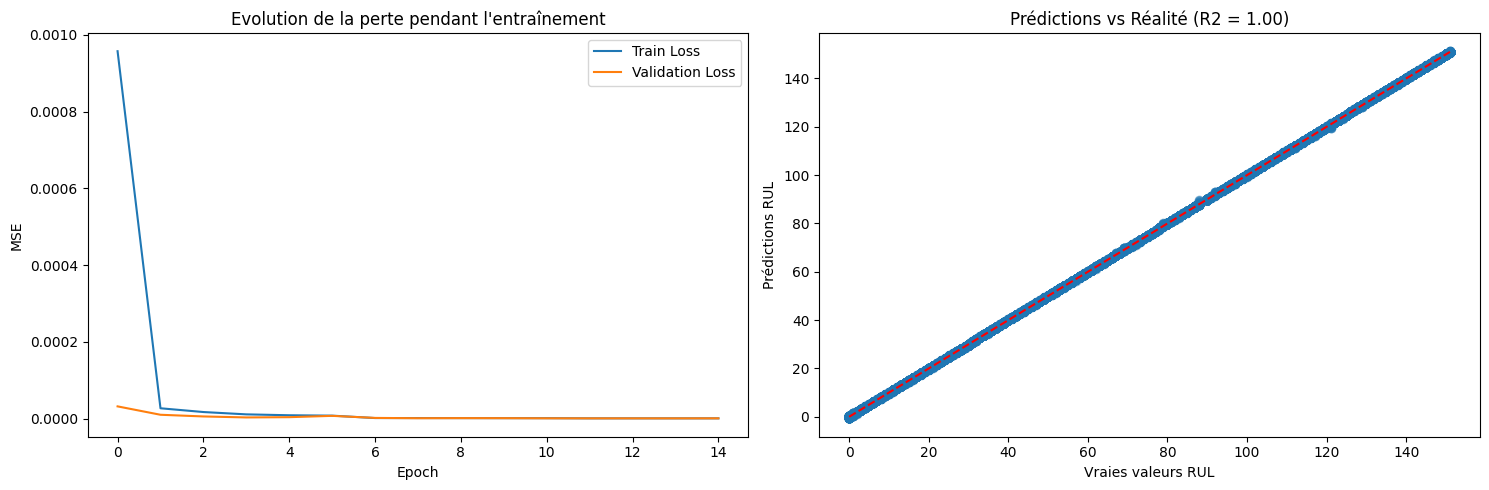

In [ ]:
print("Training BiLSTM...")
bilstm_model = build_bilstm_model(input_shape=(X_train_bilstm.shape[1], X_train_bilstm.shape[2]))
bilstm_model, history = train_bilstm_model(
    bilstm_model, X_train_bilstm, y_train_bilstm, X_test_bilstm, y_test_bilstm, 
    epochs=15, batch_size=32
)

# Predictions and inverse scaling
y_pred_scaled = bilstm_model.predict(X_test_bilstm)
y_pred = y_scaler_bilstm.inverse_transform(y_pred_scaled)
y_true = y_scaler_bilstm.inverse_transform(y_test_bilstm)

# Evaluation and visualization
mae, mse, rmse, r2 = evaluate_model(y_true, y_pred, "BiLSTM")
plot_predictions(y_true, y_pred, "BiLSTM")
plot_training_history(history, "BiLSTM")